# Part 4


model_index.json:   0%|          | 0.00/538 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

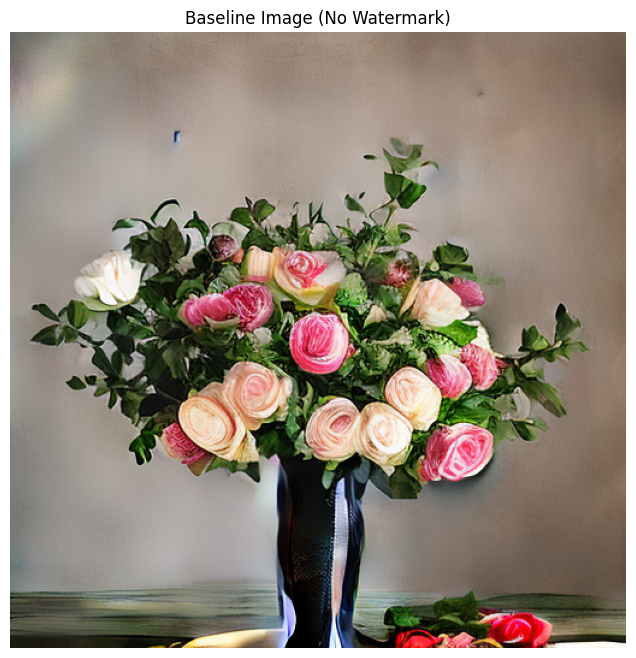

In [ ]:

import torch
from diffusers import StableDiffusionPipeline, UNet2DConditionModel
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, Dict, List, Optional, Any, Union
import numpy as np
import torch
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import requests
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch.nn.functional as F
import torch
import random
from typing import Tuple, List, Optional, Dict, Any

def setup_diffusion_pipeline() -> StableDiffusionPipeline:
    """Set up the Stable Diffusion pipeline."""
    pipe = StableDiffusionPipeline.from_pretrained("nota-ai/bk-sdm-v2-tiny", torch_dtype=torch.float16)

    # Move to appropriate device
    if torch.cuda.is_available():
        pipe = pipe.to("cuda")
    elif torch.backends.mps.is_available():
        pipe = pipe.to("mps")
    else:
        pipe = pipe.to("cpu")

    return pipe


def generate_baseline_image(pipe: StableDiffusionPipeline, prompt: str, seed: int = 8, steps: int = 5) -> Image.Image:
    """
    Generate an image with the sd model.

    Args:
        pipe: Stable Diffusion pipeline
        prompt: Text prompt for generation
        seed: Random seed for reproducibility
        steps: Number of inference steps

    Returns:
        image: Generated PIL image
    """
    # TODO: Generate an image using the pipeline
    # - Create a generator with the given seed
    #   - generator=torch.Generator(device=device).manual_seed(seed)
    # - Call the pipeline with prompt and parameters
    # - Return the first generated image
    device = pipe.device.type
    generator = torch.Generator(device=device).manual_seed(seed)
    image = pipe(prompt, num_inference_steps=steps, generator=generator).images[0]
    return image


# Set up and test
pipe = setup_diffusion_pipeline()
prompt = "a black vase holding a bouquet of roses"
baseline_image = generate_baseline_image(pipe, prompt)

# Display the baseline image
plt.figure(figsize=(8, 8))
plt.imshow(np.array(baseline_image))
plt.title("Baseline Image (No Watermark)")
plt.axis("off")
plt.show()

# Save for comparison
baseline_image.save("baseline_image.png")

In [ ]:
class FrequencyWatermarker:
    """Watermarker that modifies specific frequency bands in UNet outputs."""

    def __init__(self) -> None:
        """
        Initialize the watermarker.
        """
        self.hook_handle = None

    def watermark_hook(
        self, module: torch.nn.Module, input: Tuple[torch.Tensor, ...], output: Tuple[torch.Tensor, ...]
    ) -> Tuple[torch.Tensor, ...]:
        """
        Hook function that modifies UNet output in frequency domain.

        This function is called during the forward pass of the UNet.
        """
        # TODO: Implement frequency domain watermarking
        # - Extract the correct tensor from the output
        #   - write an adhoc hook and look at the model outputs to check
        #   - look at the implementation to see what is happening under the hood in the SD pipeline
        #   - ask a TA / check solution to  make sure you are looking at the correct tensor
        # - Apply 2D FFT and shift
        # - Modify frequencies
        #   - to start, just multiply the rectangle [:, 10:30] or similar with 0.98
        #   - You can move to more fancy and less discernible watermarks after you have completed this exercise
        # - Apply inverse FFT and modify the hook output
        to_update = output[0][1].to(dtype=torch.float32)

        # Convert to frequency domain
        fft_output = torch.fft.fft2(to_update)
        fft_shifted = torch.fft.fftshift(fft_output, dim=(-2, -1))

        # Modify specific frequency band
        start, end = (3, 25)
        fft_shifted[:, start:end, :] *= 0.98

        # Convert back to spatial domain
        fft_unshifted = torch.fft.ifftshift(fft_shifted, dim=(-2, -1))
        spatial_output = torch.fft.ifft2(fft_unshifted)

        # Update the output
        output[0][1] = spatial_output.real

        return output

    def attach(self, unet: torch.nn.Module) -> None:
        self.hook_handle = unet.register_forward_hook(self.watermark_hook)

    def detach(self) -> None:
        if self.hook_handle:
            self.hook_handle.remove()
            self.hook_handle = None

In [ ]:
def generate_watermarked_image(
    pipe: StableDiffusionPipeline, prompt: str, watermarker: FrequencyWatermarker, seed: int = 8, steps: int = 5
) -> Image.Image:
    """Generate an image with watermarking applied."""
    # Extract UNet from pipeline
    unet = pipe.components["unet"]

    # Attach watermarker
    watermarker.attach(unet)

    try:
        # Generate image
        device = pipe.device.type
        generator = torch.Generator(device=device).manual_seed(seed)
        image = pipe(prompt, num_inference_steps=steps, generator=generator).images[0]
    finally:
        # Always detach the watermarker
        watermarker.detach()

    return image


# Test watermarking
watermarker = FrequencyWatermarker()
watermarked_image = generate_watermarked_image(pipe, prompt, watermarker)

# Display comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(np.array(baseline_image))
axes[0].set_title("Baseline (No Watermark)")
axes[0].axis("off")

axes[1].imshow(np.array(watermarked_image))
axes[1].set_title("Watermarked")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Save watermarked image
watermarked_image.save("watermarked_image.png")